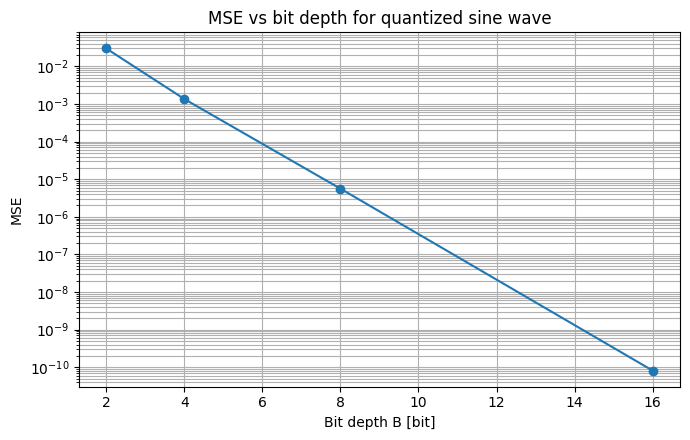

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

fs = 1000
f0 = 5
duration = 1.0
N = int(fs * duration)

n = np.arange(N)
t = n / fs
x = np.sin(2 * np.pi * f0 * t)

bit_depths = [2, 4, 8, 16]

def uniform_quantize_full_scale(x, B, xmin=-1.0, xmax=1.0):
    """
    Uniform quantization over [xmin, xmax] with L = 2^B reconstruction levels,
    including both endpoints.
    """
    L = 2**B
    delta = (xmax - xmin) / (L - 1)
    q_index = np.round((x - xmin) / delta)
    q_index = np.clip(q_index, 0, L - 1)
    x_hat = xmin + q_index * delta
    return x_hat, delta

rows = []
for B in bit_depths:
    x_hat, delta = uniform_quantize_full_scale(x, B)
    e = x_hat - x
    mse = np.mean(e**2)
    rows.append({
        "Bit depth B": B,
        "Levels 2^B": 2**B,
        "Step size Delta": delta,
        "MSE": mse,
    })

df = pd.DataFrame(rows)

plt.figure(figsize=(7, 4.5))
plt.plot(df["Bit depth B"], df["MSE"], marker="o")
plt.yscale("log")
plt.xlabel("Bit depth B [bit]")
plt.ylabel("MSE")
plt.title("MSE vs bit depth for quantized sine wave")
plt.grid(True, which="both")
plt.tight_layout()

plt.show()
